In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **IMPORTING DATASET**

In [2]:
df = pd.read_csv(r"C:\Users\sudhanshu\Downloads\adult.csv")

In [3]:
df.shape

(32561, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [5]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [6]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## **CLEANING DATASET**

In [7]:
print(df.workclass.value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64


In [8]:
df = df[df['workclass'] != 'Without-pay']
df = df[df['workclass'] != 'Never-worked']

In [10]:
df['native.country'].replace({'?':'others'}, inplace=True)

In [11]:
print(df['income'].value_counts())

income
<=50K    24699
>50K      7841
Name: count, dtype: int64


In [12]:
df = df[df['marital.status'] != 'Married-AF-spouse']

In [13]:
df = df[df['occupation'] != 'Armed-Forces']

In [14]:
df = df[df['education'] != '1st-4th']
df = df[df['education'] != '5th-6th']
df = df[df['education'] != 'Preschool']

In [15]:
df.occupation.replace({'?':'others'}, inplace=True)

In [16]:
df.workclass.replace({'?':'others'}, inplace=True)

## **FINDING AND HANDLING OUTLIER**

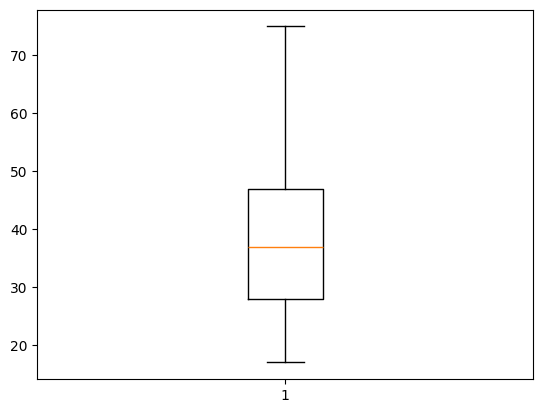

In [20]:
plt.boxplot(df['age'])
plt.show()

In [19]:
df = df[(df['age']<=75) & (df['age']>=17)]
df.shape

(31726, 15)

In [21]:
df.drop(columns=['education'], inplace=True)

## **BUILDING MACHINE LEARNING MODEL**

In [26]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['workclass'] = encoder.fit_transform(df['workclass'])
df['marital.status'] = encoder.fit_transform(df['marital.status'])
df['occupation'] = encoder.fit_transform(df['occupation'])
df['relationship'] = encoder.fit_transform(df['relationship'])
df['race'] = encoder.fit_transform(df['race'])
df['sex'] = encoder.fit_transform(df['sex'])
df['native.country'] = encoder.fit_transform(df['native.country'])
df.head(10)

,age,workclass,fnlwgt,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
2,66,6,186061,10,5,13,4,2,0,0,4356,40,38,<=50K
3,54,2,140359,4,0,5,4,4,0,0,3900,40,38,<=50K
4,41,2,264663,10,4,8,3,4,0,0,3900,40,38,<=50K
5,34,2,216864,9,0,6,4,4,0,0,3770,45,38,<=50K
6,38,2,150601,6,4,0,4,4,1,0,3770,40,38,<=50K
7,74,5,88638,16,3,8,2,4,0,0,3683,20,38,>50K
8,68,0,422013,9,0,8,1,4,0,0,3683,40,38,<=50K
9,41,2,70037,10,3,1,4,4,1,0,3004,60,41,>50K
10,45,2,172274,16,0,8,4,2,0,0,3004,35,38,>50K
11,38,4,164526,15,3,8,1,4,1,0,2824,45,38,>50K


In [22]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education.num', 'marital.status',
       'occupation', 'relationship', 'race', 'sex', 'capital.gain',
       'capital.loss', 'hours.per.week', 'native.country', 'income'],
      dtype='object')

In [28]:
x = df.drop(columns=['income'])
y = df['income']
x.head(10)

,age,workclass,fnlwgt,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
2,66,6,186061,10,5,13,4,2,0,0,4356,40,38
3,54,2,140359,4,0,5,4,4,0,0,3900,40,38
4,41,2,264663,10,4,8,3,4,0,0,3900,40,38
5,34,2,216864,9,0,6,4,4,0,0,3770,45,38
6,38,2,150601,6,4,0,4,4,1,0,3770,40,38
7,74,5,88638,16,3,8,2,4,0,0,3683,20,38
8,68,0,422013,9,0,8,1,4,0,0,3683,40,38
9,41,2,70037,10,3,1,4,4,1,0,3004,60,41
10,45,2,172274,16,0,8,4,2,0,0,3004,35,38
11,38,4,164526,15,3,8,1,4,1,0,2824,45,38


In [31]:
y.head(10)

2     <=50K
3     <=50K
4     <=50K
5     <=50K
6     <=50K
7      >50K
8     <=50K
9      >50K
10     >50K
11     >50K
Name: income, dtype: object

In [33]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

x = scaler.fit_transform(x)
x

array([[0.84482759, 1.        , 0.11802067, ..., 1.        , 0.39795918,
        0.92682927],
       [0.63793103, 0.33333333, 0.08698198, ..., 0.8953168 , 0.39795918,
        0.92682927],
       [0.4137931 , 0.33333333, 0.17140354, ..., 0.8953168 , 0.39795918,
        0.92682927],
       ...,
       [0.39655172, 0.33333333, 0.09650032, ..., 0.        , 0.39795918,
        0.92682927],
       [0.70689655, 0.33333333, 0.09482688, ..., 0.        , 0.39795918,
        0.92682927],
       [0.0862069 , 0.33333333, 0.12849934, ..., 0.        , 0.19387755,
        0.92682927]], shape=(31726, 13))

## **MODEL TRAINING**

In [35]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=23, stratify=y)

In [36]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(xtrain, ytrain)
predict = knn.predict(xtest)
predict

array(['>50K', '<=50K', '<=50K', ..., '<=50K', '<=50K', '>50K'],
      shape=(6346,), dtype=object)

In [37]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest, predict)

0.8247715096123542

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

scaler = StandardScaler()

xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

In [45]:
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(solver='lbfgs', alpha=1e-5,
                   hidden_layer_sizes=(5, 2), max_iter=2000, random_state=1)
clf.fit(xtrain, ytrain)
predict1 = clf.predict(xtest)
predict1

array(['>50K', '<=50K', '<=50K', ..., '<=50K', '<=50K', '>50K'],
      shape=(6346,), dtype='<U5')

In [46]:
accuracy_score(ytest,predict1)

0.8487236054207374

In [47]:
from sklearn.linear_model import LogisticRegression
reg = LogisticRegression()
reg.fit(xtrain, ytrain)
predict3 = reg.predict(xtest)
predict3

array(['<=50K', '<=50K', '<=50K', ..., '<=50K', '<=50K', '>50K'],
      shape=(6346,), dtype=object)

In [48]:
accuracy_score(ytest, predict3)

0.8233532934131736